# 📊 Synthetic Data Project STAIML


## STEP 1: Data Acquisition
**Explanation:** We load the dataset using `read_csv()`. This is like opening an Excel file. The dataset contains patient details and whether they have diabetes.

In [1]:
import pandas as pd

df = pd.read_csv("/content/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## STEP 2: Missing Data Handling
**Explanation:** Some values are 0 which is not possible (like 0 glucose). So we replace them with NaN and fill with mean (average).

In [2]:
import numpy as np

cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
df[cols] = df[cols].replace(0, np.nan)

for col in cols:
    df[col].fillna(df[col].mean(), inplace=True)

df.isnull().sum()

/tmp/ipykernel_21848/2339717528.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


## STEP 3: Outlier Detection
**Explanation:** Outliers are extreme values. We visualize them using boxplots. Points outside the box are outliers.

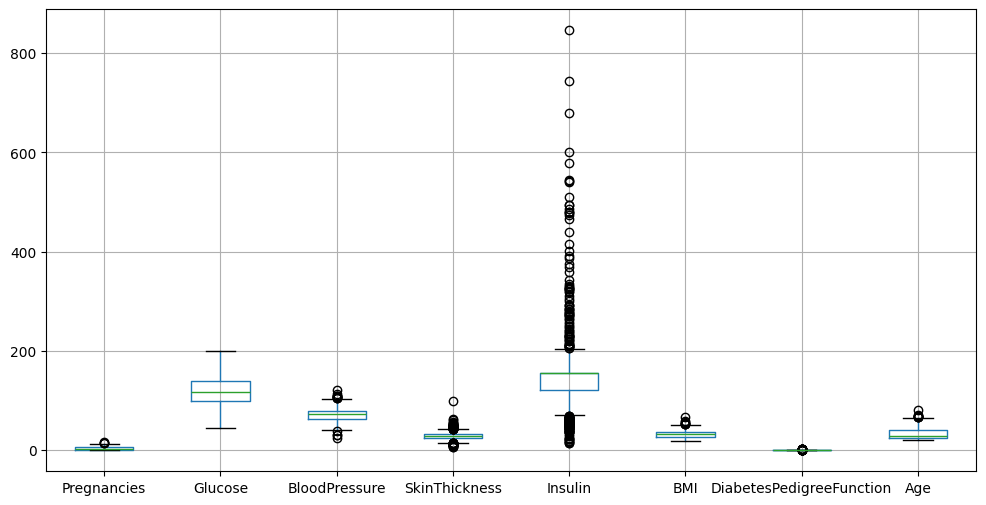

In [3]:
import matplotlib.pyplot as plt

features = [col for col in df.columns if col != 'Outcome']

df[features].boxplot(figsize=(12,6))
plt.show()

## STEP 4: Univariate Analysis
**Explanation:** We study one feature at a time using histograms to understand distribution, spread, and skewness.

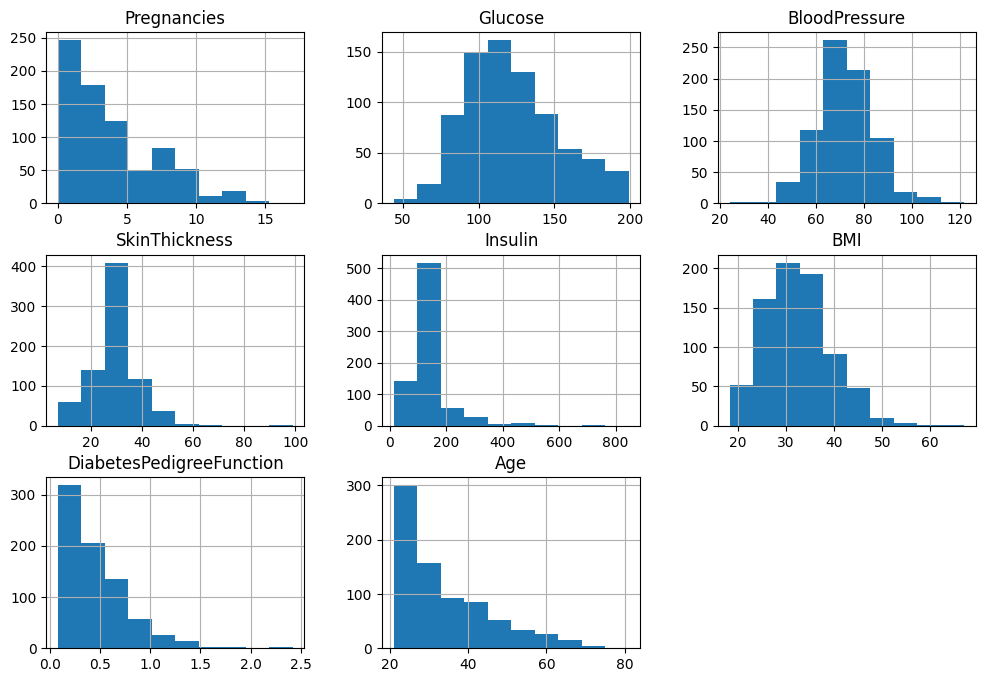

In [4]:
df[features].hist(figsize=(12,8))
plt.show()

## STEP 5: Bivariate Analysis
**Explanation:** We study relationships between variables. Heatmap shows correlation, scatter plot shows pattern between Glucose and BMI.

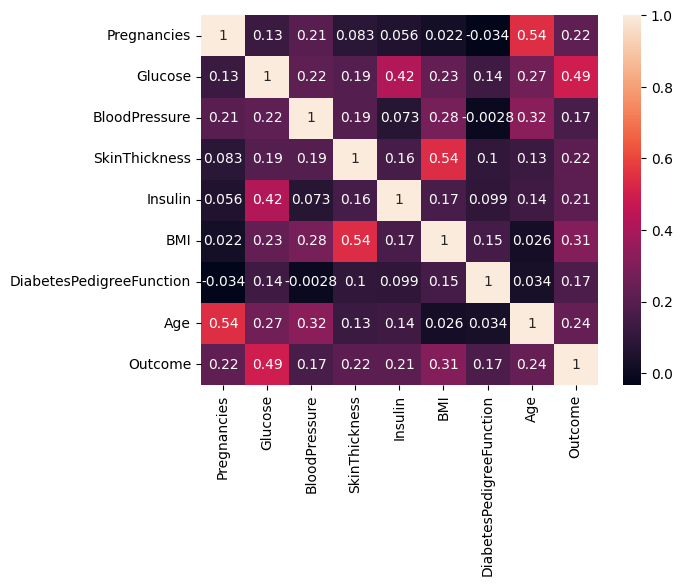

In [5]:
import seaborn as sns

sns.heatmap(df.corr(), annot=True)
plt.show()

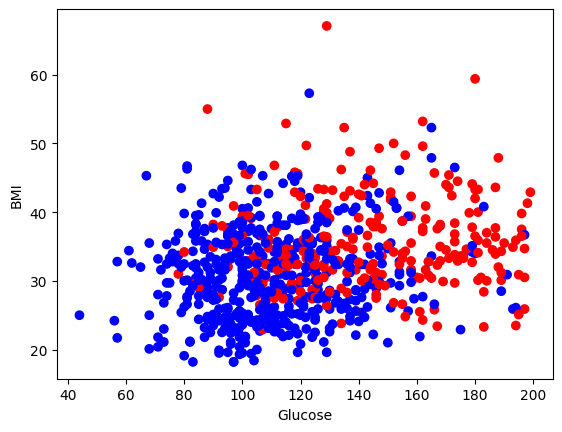

In [6]:
colors = df['Outcome'].map({0:'blue',1:'red'})
plt.scatter(df['Glucose'], df['BMI'], c=colors)
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.show()

## STEP 6: Encoding
**Explanation:** Machine learning models understand numbers, not text. So we convert text labels into numeric form using LabelEncoder.

In [7]:
from sklearn.preprocessing import LabelEncoder

df['Outcome_text'] = df['Outcome'].map({0:'No_Diabetes',1:'Diabetes'})

le = LabelEncoder()
df['Outcome_encoded'] = le.fit_transform(df['Outcome_text'])

df[['Outcome_text','Outcome_encoded']].drop_duplicates()

,Outcome_text,Outcome_encoded
0,Diabetes,0
1,No_Diabetes,1


## STEP 7: Synthetic Data Generation
**Explanation:** We generate fake data using mean and standard deviation. This creates realistic but artificial data.

In [8]:
import numpy as np

def generate_synthetic(real_df, n_samples=500):
    rows = []
    for label in [0,1]:
        group = real_df[real_df['Outcome'] == label]
        n = int(n_samples * len(group) / len(real_df))
        for _ in range(n):
            row = {}
            for col in features:
                mean = group[col].mean()
                std  = group[col].std()
                value = np.random.normal(mean, std)
                value = np.clip(value, real_df[col].min(), real_df[col].max())
                row[col] = value
            row['Outcome'] = label
            rows.append(row)
    return pd.DataFrame(rows)

np.random.seed(42)
syn_df = generate_synthetic(df)

syn_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,4.796678,107.292633,78.662991,40.805186,124.540662,29.365425,0.902053,40.144163,0
1,1.881509,124.120610,65.406345,23.782187,160.470150,18.442969,0.078000,24.629423,0
2,0.242102,118.477391,60.101731,15.679887,252.814165,29.419809,0.449931,21.000000,0
3,1.655497,113.451801,57.202854,30.984478,96.884293,28.991031,0.249772,52.801742,0
4,3.257276,84.566616,80.749208,17.318710,157.972399,18.200000,0.078000,33.486909,0


## STEP 8: ML Model Training
**Explanation:** We train models on real and synthetic data separately and compare accuracy to check quality of synthetic data.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df[features]
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

X_syn = scaler.transform(syn_df[features])
y_syn = syn_df['Outcome']

In [12]:
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)
print("Shape of X_syn:", X_syn.shape)
print("Shape of y_syn:", y_syn.shape)

print("\nFirst 5 rows of X_train (scaled):")
print(X_train[:5])

print("\nFirst 5 rows of y_train:")
print(y_train.head())

print("\nFirst 5 rows of X_syn (scaled):")
print(X_syn[:5])

print("\nFirst 5 rows of y_syn:")
print(y_syn.head())

Shape of X_train: (614, 8)
Shape of X_test: (154, 8)
Shape of y_train: (614,)
Shape of y_test: (154,)
Shape of X_syn: (499, 8)
Shape of y_syn: (499,)

First 5 rows of X_train (scaled):
[[-0.85135507 -1.0575301  -0.82797293 -1.92309528 -1.40194593 -0.76981811
   0.31079384 -0.79216928]
 [ 0.35657564  0.14339202  0.47653222 -0.23479451 -1.67171513 -0.41783762
  -0.11643851  0.56103382]
 [-0.5493724  -0.55714588 -1.15409922  1.2283995  -0.74679214  0.35945263
  -0.76486207 -0.70759409]
 [-0.85135507  0.81057098 -1.31716237  0.00758016  0.04386573 -0.40317177
   0.26231357 -0.36929331]
 [-1.15333775 -0.89073536 -0.66490979  1.11584612 -0.60548446  1.78204045
  -0.33762972 -0.96131967]]

First 5 rows of y_train:
353    0
711    0
373    0
46     0
682    0
Name: Outcome, dtype: int64

First 5 rows of X_syn (scaled):
[[ 0.295176   -0.48066604  0.53058689  1.31902594 -0.35446214 -0.45224003
   1.28662084  0.57322647]
 [-0.58515459  0.08069755 -0.55024827 -0.5969702   0.10709355 -2.05411152
  

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Random Forest": RandomForestClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    real_acc = accuracy_score(y_test, model.predict(X_test))

    model.fit(X_syn, y_syn)
    syn_acc = accuracy_score(y_test, model.predict(X_test))

    print(f"{name} → Real: {round(real_acc*100,2)}% | Synthetic: {round(syn_acc*100,2)}%")

Logistic Regression → Real: 69.48% | Synthetic: 70.13%
Random Forest → Real: 74.03% | Synthetic: 70.78%


## Confusion Matrix
**Explanation:** Shows how many predictions were correct and incorrect.

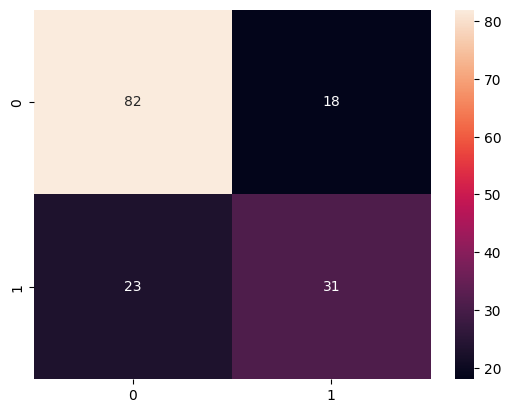

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

model = RandomForestClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

## Conclusion

This project successfully demonstrates the process of generating synthetic data and evaluating its utility. After performing essential data preprocessing steps such as missing value imputation, and exploratory data analysis, we proceeded to generate synthetic data based on the characteristics of the real dataset.

The key finding is that machine learning models trained on this synthetic data achieved comparable accuracy to models trained on the original real data. Specifically, both Logistic Regression and Random Forest models showed similar performance metrics, with synthetic data models yielding accuracies very close to their real data counterparts. For instance, Logistic Regression achieved approximately 69.48% on real data and 70.13% on synthetic data, while Random Forest achieved 74.03% on real data and 70.78% on synthetic data.

This outcome is significant as it validates the effectiveness of our synthetic data generation approach. It suggests that the synthetic dataset retains the statistical properties and predictive power of the original data, making it a valuable privacy-preserving alternative. Such synthetic datasets can be safely shared for research, development, and testing purposes without exposing sensitive real patient information, thus addressing critical privacy concerns in data-driven applications.